# 📊 Superstore Sales Data Visualization

## Project Overview

This project focuses on visualizing Superstore sales data using Python to identify sales trends, product performance, regional patterns, and other business insights.

In [ ]:
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## 2. Load Cleaned Dataset

In [2]:
df = pd.read_csv("Superstore_Cleaned.csv")

## 3. Dataset Overview

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7


In [28]:
df.shape

(9800, 19)

In [4]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Shipping Days']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9800 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
 18  Shipping Days  9800

### Observation

The dataset contains 9,800 records and 19 columns. All columns contain 9,800 non-null values, indicating that no missing values are present in the loaded dataset. Order ID and other identifier fields are stored as strings, while Order Date and Ship Date are currently stored as strings and Postal Code is stored as a numeric field. These fields will be converted into suitable formats for visualization where required.

## 4. Prepare Data for Visualization

In [12]:

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])


df["Postal Code"] = (
    df["Postal Code"]
    .astype("float64")
    .astype(str)
    .str.zfill(5)
)

In [15]:
df[["Order Date", "Ship Date", "Postal Code"]].dtypes

Order Date     datetime64[us]
Ship Date      datetime64[us]
Postal Code               str
dtype: object

### Observation

The date columns were converted to datetime format to support time-based analysis and visualization. Postal Code was converted to string format because it represents an identifier rather than a numerical measure.

## 5. Sales Distribution

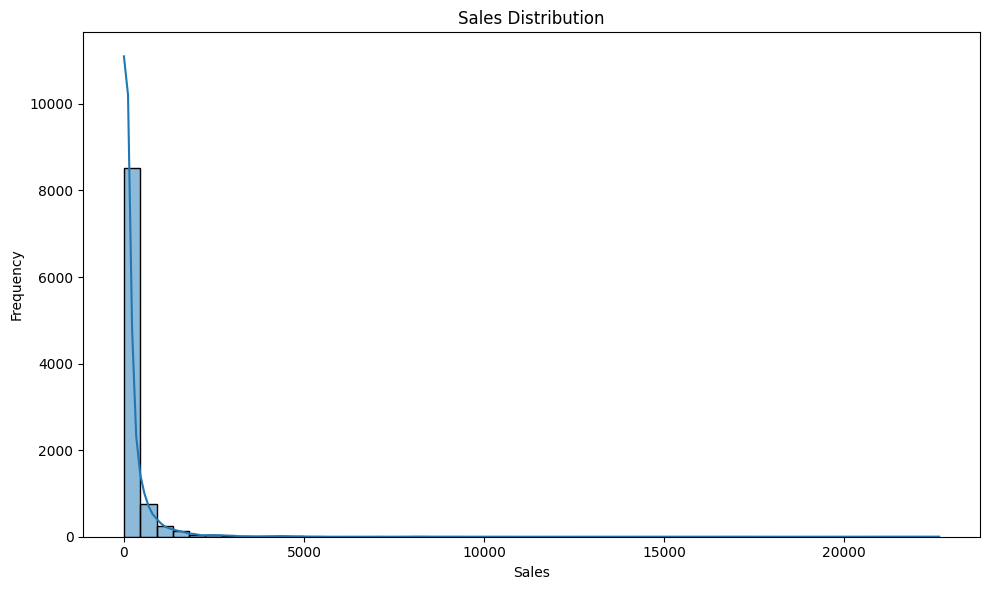

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The sales distribution is strongly right-skewed, with most values concentrated between 0 and 1,000. A small number of high-value transactions extend the distribution's tail beyond 15,000, indicating the presence of extreme sales observations.

## 6. Monthly Sales Trend

This visualization analyzes monthly sales patterns to identify periods of higher and lower sales activity throughout the year.

In [36]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.month)["Sales"]
    .sum()
)

monthly_sales

Order Date
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64

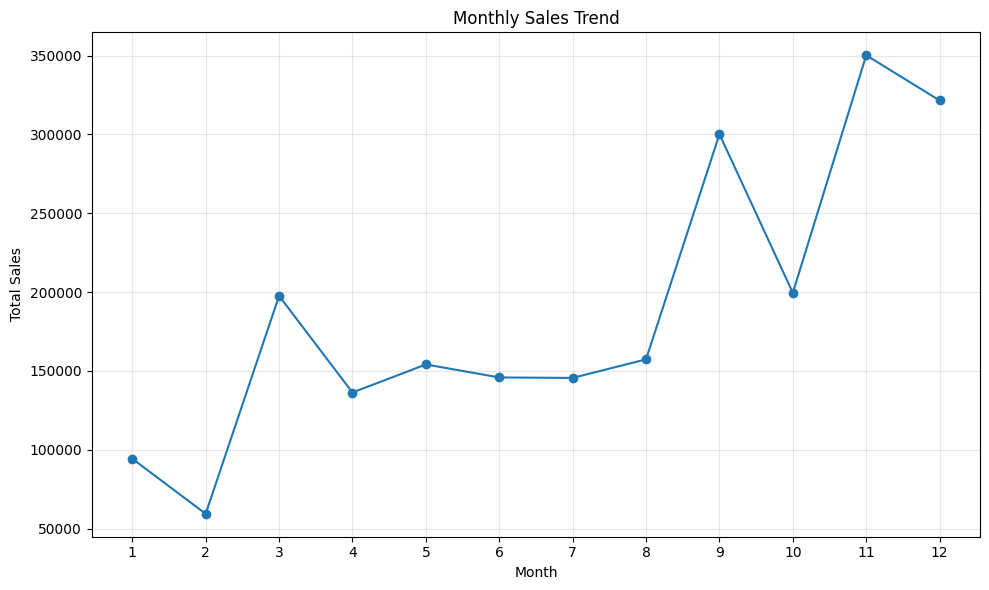

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

Monthly sales show noticeable fluctuations throughout the year. Sales are relatively low in January and February, followed by a strong increase in March. Sales remain at a moderate level from April to August before increasing substantially from September onward. November records the highest monthly sales, followed by December.

## 7. Sales by Category

This visualization compares total sales across product categories to identify which categories contribute most to overall sales.

In [38]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

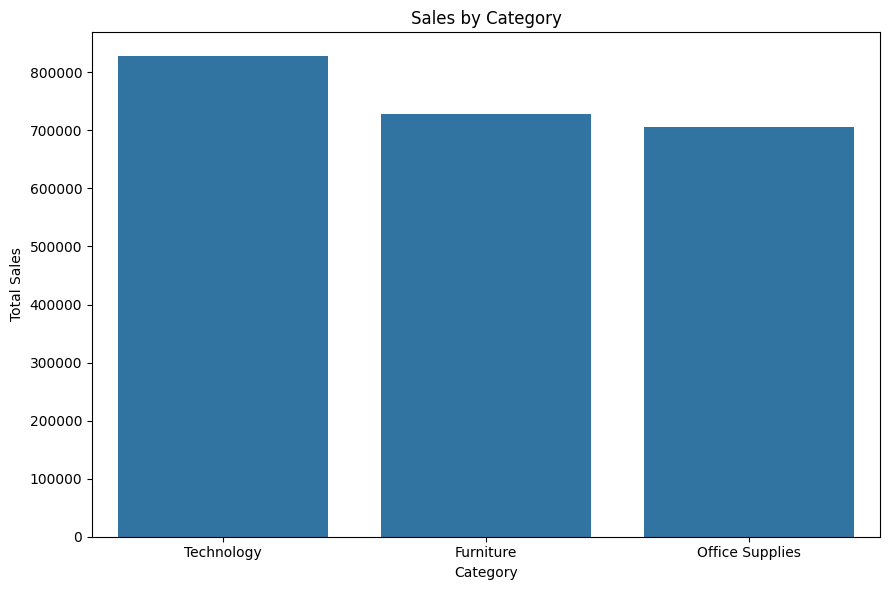

In [39]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

Technology leads in total sales, followed by Furniture and Office Supplies. The three categories have relatively similar sales levels, with Technology showing a moderate lead over the other two categories.

## 8. Sales by Sub-Category

This visualization compares total sales across product sub-categories to identify the strongest and weakest contributors to overall sales.

In [42]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

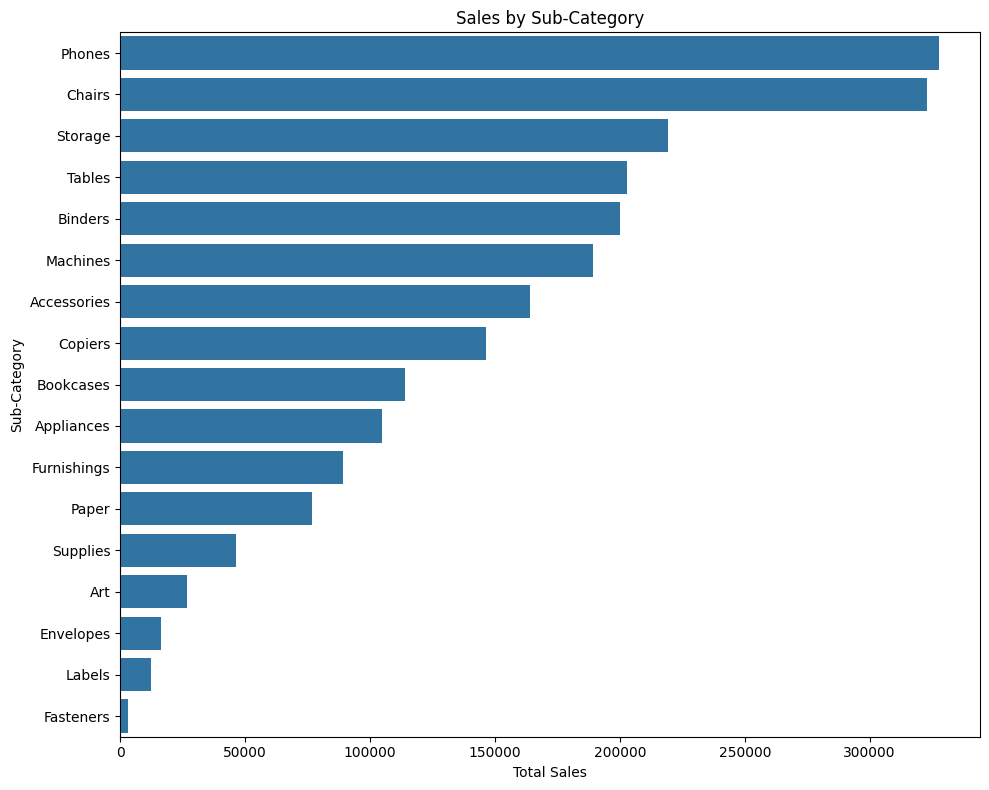

In [43]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

### Observation

Phones and Chairs are the top-performing sub-categories, contributing significantly more sales than most other sub-categories. Fasteners, Labels, and Envelopes generate the lowest sales, highlighting a substantial gap between the highest- and lowest-performing sub-categories.

## 9. Sales by Region

This visualization compares total sales across different regions to identify regional sales performance and highlight the strongest and weakest markets.

In [44]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

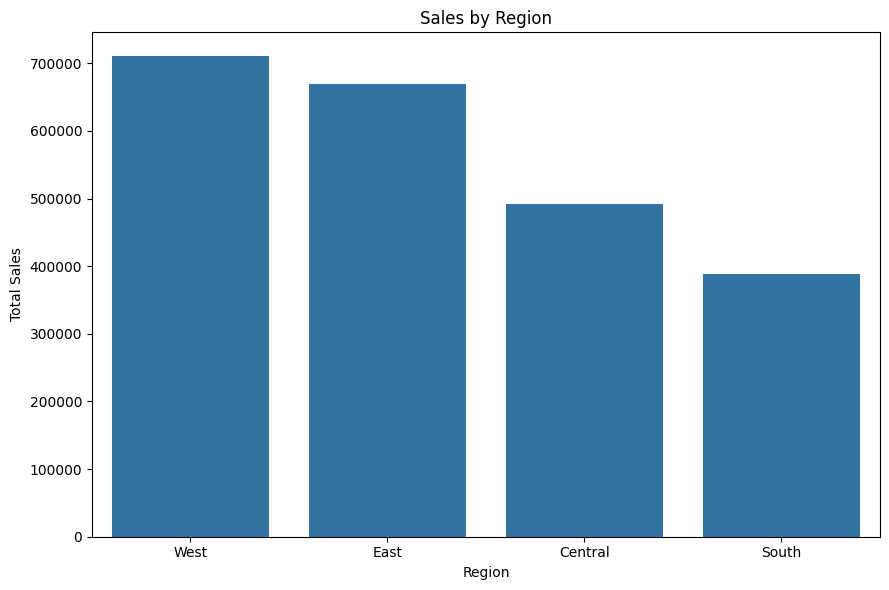

In [45]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

West and East are the highest-performing regions in terms of total sales, while Central and South generate lower sales. West leads all regions, whereas South records the lowest sales, with approximately 55% of West's sales.

## 10. Sales by Segment

This visualization compares total sales across customer segments to identify the strongest customer segment and understand its contribution to overall sales.

In [46]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

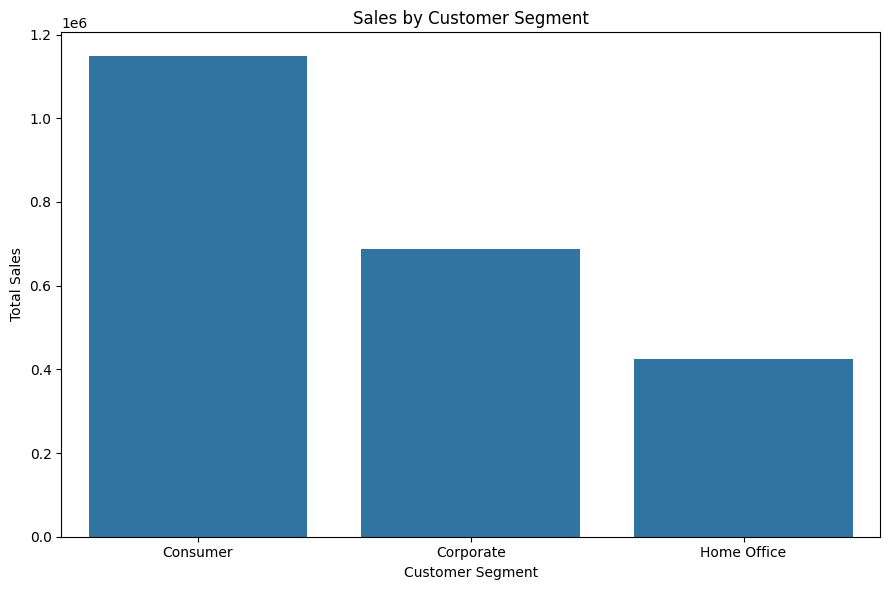

In [47]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

The Consumer segment generates the highest sales, well above the Corporate and Home Office segments. Home Office contributes the least, with sales amounting to approximately 37% of Consumer segment sales.

## 11. Top 10 Products by Sales

This visualization identifies the top 10 products based on total sales to highlight the highest-performing products in the dataset.

In [48]:
top_10_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

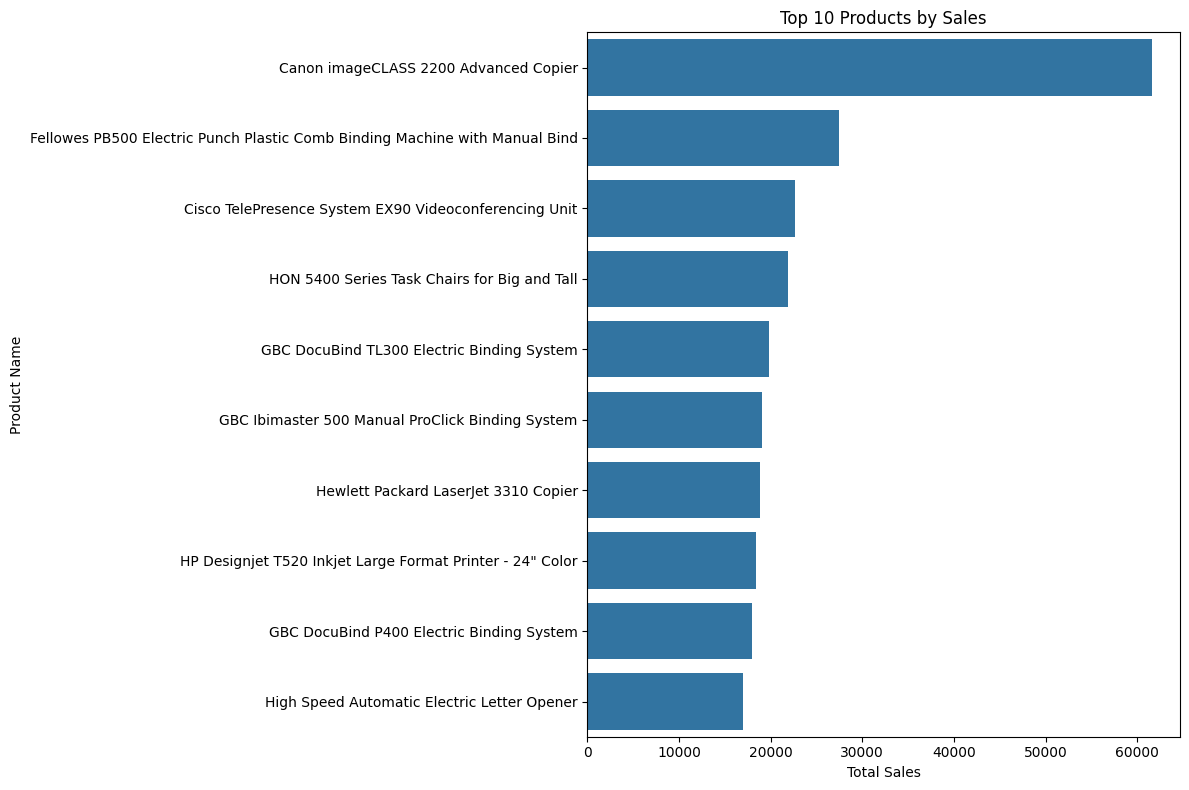

In [49]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

### Observation

The Canon imageCLASS 2200 Advanced Copier is the clear top-performing product, generating substantially higher sales than the other products in the top 10. The remaining products show comparatively lower and more closely grouped sales levels, with printers, copiers, binding systems, and other office equipment featuring prominently among the highest-selling products.

## 12. Sales by Ship Mode

This visualization compares total sales across different shipping modes to understand their contribution to overall sales.

In [50]:
ship_mode_sales = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

ship_mode_sales

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64

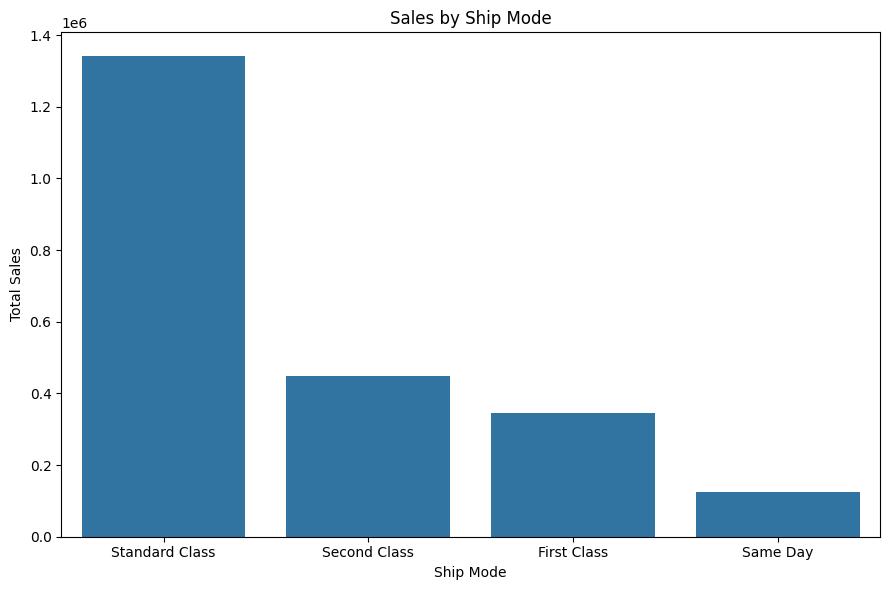

In [51]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=ship_mode_sales.index,
    y=ship_mode_sales.values
)

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

Standard Class generates the highest sales by a substantial margin, exceeding the combined sales of the other three shipping modes. Same Day records the lowest sales contribution, while Second Class and First Class fall between the two extremes.

## 13. Sales by Region and Category

This analysis compares sales across regions and product categories to identify regional differences in category performance.

In [52]:
region_category_sales = (
    df.groupby(["Region", "Category"])["Sales"]
    .sum()
    .unstack()
)

region_category_sales

Category,Furniture,Office Supplies,Technology
Region,,,
Central,160317.4622,163590.243,168739.208
East,206461.3880,199940.811,263116.527
South,116531.4800,124424.771,148195.208
West,245348.2455,217466.509,247404.930


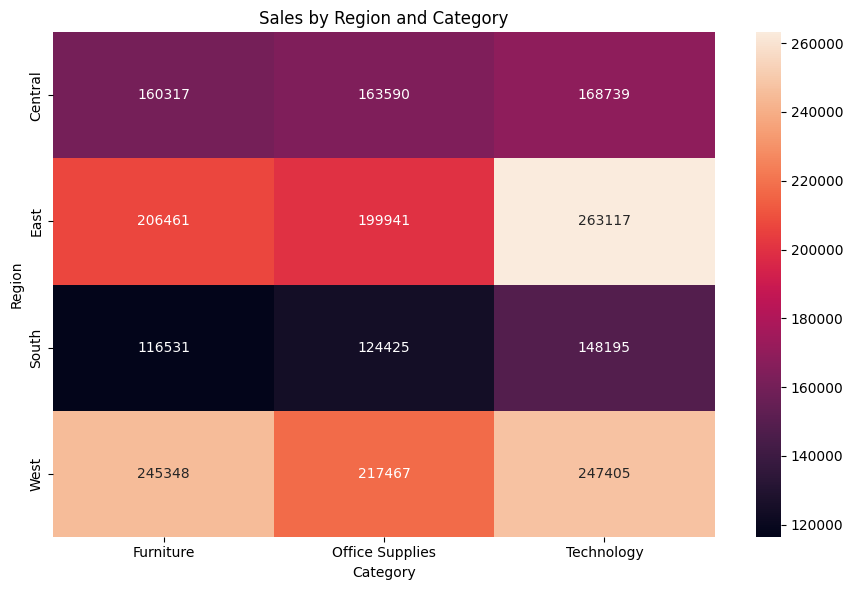

In [53]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    region_category_sales,
    annot=True,
    fmt=".0f"
)

plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

East and West regions show the strongest sales performance across the three categories, with Technology in the East (263,117) representing the highest single region-category combination. The South region records the lowest sales across all categories, with Furniture showing the lowest value at approximately 116,531.

## 14. Monthly Sales by Category

This analysis compares monthly sales trends across product categories to identify seasonal patterns and differences in category performance throughout the year.

In [54]:
monthly_category_sales = (
    df.groupby([df["Order Date"].dt.month, "Category"])["Sales"]
    .sum()
    .unstack()
)

monthly_category_sales

Category,Furniture,Office Supplies,Technology
Order Date,,,
1,31510.1236,33006.581,29774.925
2,15673.9604,20612.313,23084.842
3,46132.1122,53941.085,97500.390
4,40698.5836,48298.814,47285.603
5,48137.8707,42498.666,63450.187
6,50168.4633,47488.337,48180.723
7,48433.6720,42970.631,54131.386
8,44092.9830,61549.688,51673.256
9,104174.0847,101075.278,94854.049


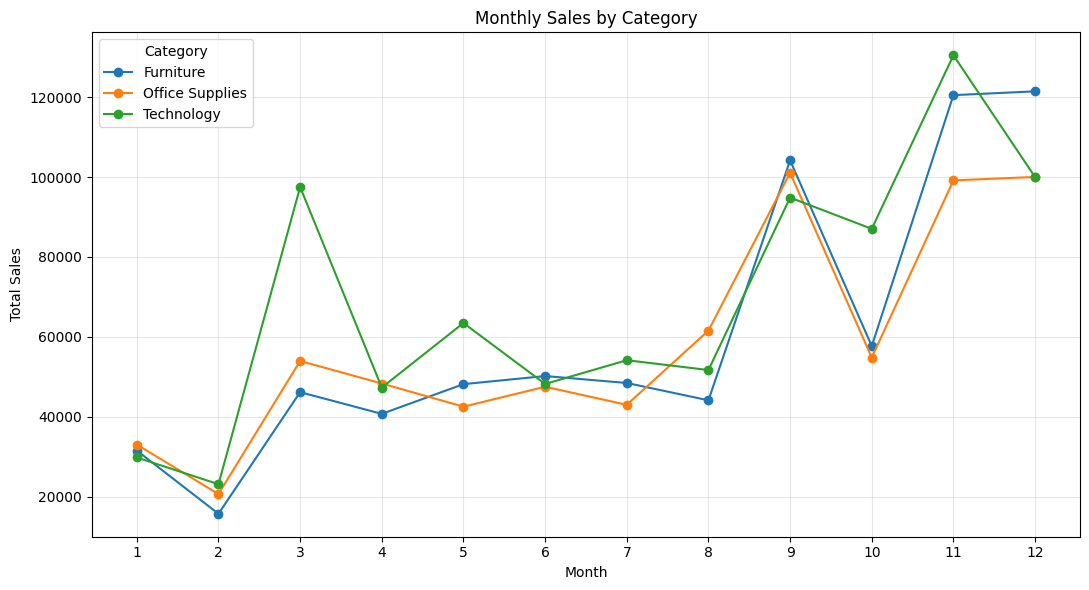

In [55]:
plt.figure(figsize=(11, 6))

for category in monthly_category_sales.columns:
    plt.plot(
        monthly_category_sales.index,
        monthly_category_sales[category],
        marker="o",
        label=category
    )

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.legend(title="Category")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

All three categories record their lowest monthly sales in February, followed by a strong increase in March. Technology shows the most noticeable fluctuations, with major peaks in March (97.5K) and November (130.5K). Furniture records its highest sales in December (121.5K), while Office Supplies reaches its highest level in September (101.1K). Sales across all categories increase substantially toward the end of the year.

## 15. Shipping Days Analysis

This analysis examines shipping duration to understand delivery performance and identify common shipping-time patterns.

In [56]:
shipping_summary = df["Shipping Days"].describe()

shipping_summary

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

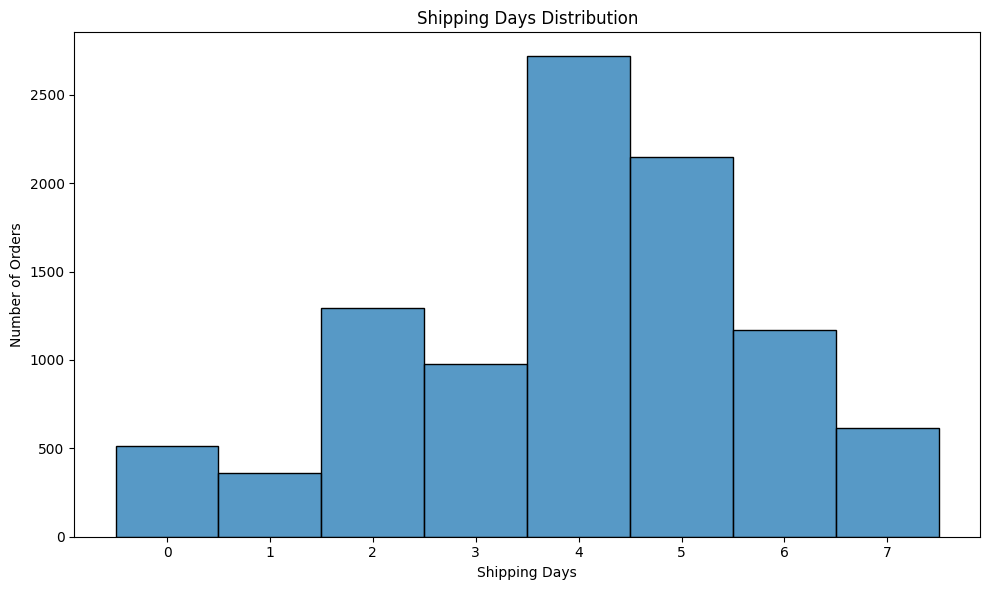

In [57]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Shipping Days"],
    bins=8,
    discrete=True
)

plt.title("Shipping Days Distribution")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Observation

Most orders are shipped within 4–5 days, with the distribution centered around this range. Very few orders are shipped on the same day (0 days) or take more than 6 days, indicating a relatively consistent shipping duration across the dataset.

## 16. Sales vs Shipping Days

This analysis examines the relationship between shipping duration and sales to identify any noticeable patterns in sales across different shipping times.

In [58]:
avg_sales_shipping = (
    df.groupby("Shipping Days")["Sales"]
    .mean()
)

avg_sales_shipping

Shipping Days
0    236.894173
1    183.746874
2    277.107123
3    205.097288
4    228.675412
5    229.254844
6    201.461437
7    266.950228
Name: Sales, dtype: float64

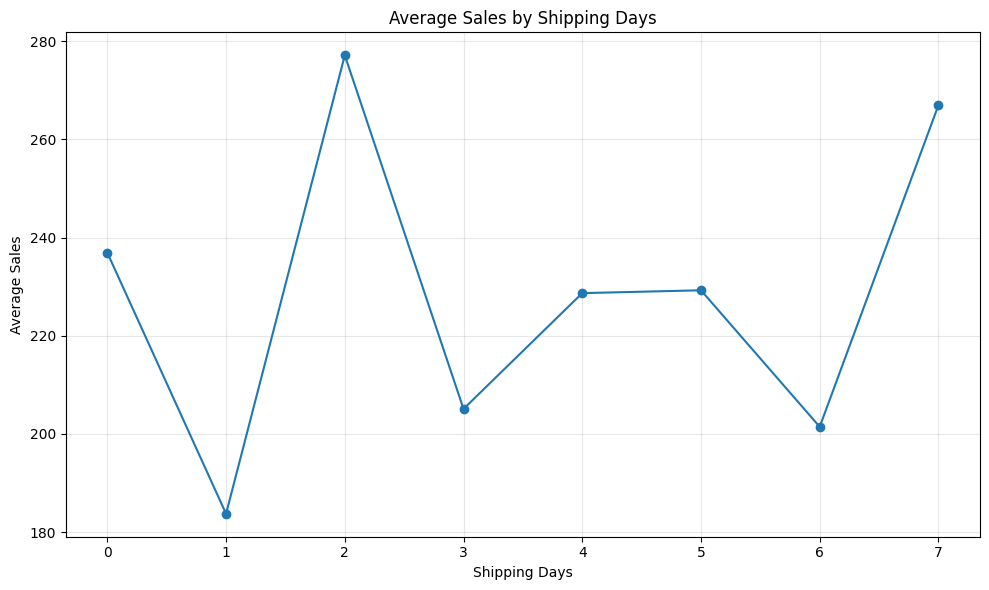

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    avg_sales_shipping.index,
    avg_sales_shipping.values,
    marker="o"
)

plt.title("Average Sales by Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Average Sales")

plt.xticks(range(0, 8))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

Average sales fluctuate across different shipping durations, ranging from approximately 184 to 277. The highest average sales occur at 2 and 7 shipping days, while the lowest occur at 1 day. Overall, no clear increasing or decreasing pattern is observed between shipping duration and average sales.

## 17. Key Business Insights

The analysis reveals several important business insights from the Superstore sales data:

1. **Sales Distribution:** Sales are strongly right-skewed, with most orders having relatively low sales values and a small number of high-value orders.

2. **Monthly Performance:** Sales fluctuate throughout the year, with a significant increase toward the end of the year. November and December are among the strongest months.

3. **Category Performance:** Technology generates the highest total sales among the three major categories, followed by Furniture and Office Supplies.

4. **Sub-Category Performance:** Phones and Chairs are the strongest-performing sub-categories, while Fasteners, Labels, and Envelopes generate the lowest sales.

5. **Regional Performance:** West and East are the strongest regions in terms of sales, while South records the lowest overall sales.

6. **Customer Segment:** Consumer customers contribute the highest sales, followed by Corporate and Home Office segments.

7. **Top Products:** The Canon imageCLASS 2200 Advanced Copier is the clear top-selling product, generating substantially higher sales than the other leading products.

8. **Shipping Mode:** Standard Class generates the largest share of sales by a substantial margin, while Same Day contributes the least.

9. **Region and Category:** Technology sales in the East represent the highest region-category combination, while South Furniture records the lowest.

10. **Shipping Duration:** Most orders are shipped within approximately 4–5 days, showing a relatively consistent shipping duration.

11. **Sales and Shipping Duration:** Average sales fluctuate across shipping durations without a clear increasing or decreasing pattern.

## 18. Final Conclusion

The Superstore sales analysis provided a clear overview of sales performance across time, products, categories, regions, customer segments, and shipping patterns. Technology generated the highest overall sales, while the West and East regions were the strongest-performing regions. Consumer customers contributed the largest share of sales, and Phones and Chairs were among the top-performing sub-categories.

The analysis also revealed strong seasonal variation in monthly sales, a highly right-skewed sales distribution, and relatively consistent shipping durations. Overall, the visualizations helped transform the cleaned dataset into meaningful business insights that can support better understanding of sales performance and customer behavior.

## 19. Final Data Quality Check

In [10]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Shape: (9800, 19)
Missing values: 0
Duplicate rows: 0

Data types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code                 str
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Shipping Days             int64
dtype: object
